# 19 — HbA1c: All Interactions

**Purpose**: Systematically test every remaining SDOH, psychosocial, and clinical
predictor against HbA1c. NB13 covered study group, psychosocial burden tertiles,
food/housing insecurity, PAID-5, and CES-D. This notebook fills all remaining gaps:
comorbidity cluster, neighborhood safety, substance exposure, healthcare access,
OTC burden, discrimination (standalone), DML gap domains, site variation, and a
multivariate OLS regression.

**Inputs**: `13_hba1c_per_person.csv`, `features_with_cluster.csv` (Google Drive)

**Outputs**: `19_hba1c_all_interactions_summary.csv`, `19_hba1c_regression_table.csv`

**Runtime**: Designed for Cursor IDE with Colab kernel, or Google Colab directly.
No Azure connection needed.

In [1]:
# ── 1. Environment Setup ───────────────────────────────────────────
import subprocess, sys

packages = ['scipy', 'seaborn', 'statsmodels']
for pkg in packages:
    subprocess.run([sys.executable, '-m', 'pip', 'install', pkg, '-q'],
                   capture_output=True, text=True)

import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy import stats
from itertools import combinations

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('Set2')
pd.set_option('display.float_format', '{:.3f}'.format)

STUDY_GROUP_ORDER = ['Healthy', 'Pre-DM', 'Oral Med', 'Insulin']
STUDY_GROUP_MAP   = {0: 'Healthy', 1: 'Pre-DM', 2: 'Oral Med', 3: 'Insulin'}
STUDY_GROUP_PAL   = dict(zip(STUDY_GROUP_ORDER, sns.color_palette('Set2', 4)))

print('Environment ready.')

Environment ready.


In [2]:
# ── 2. Google Drive Mount ──────────────────────────────────────────
from google.colab import drive
drive.mount('/content/drive', force_remount=False)
out_dir = Path('/content/drive/MyDrive/ORGANIZATIONS/ucsftech_outputs')
out_dir.mkdir(parents=True, exist_ok=True)
print(f'Output directory: {out_dir}')

Mounted at /content/drive
Output directory: /content/drive/MyDrive/ORGANIZATIONS/ucsftech_outputs


In [3]:
# ── 3. Load & Merge Data ───────────────────────────────────────────
features = pd.read_csv(out_dir / 'features_with_cluster.csv')
hba1c_df = pd.read_csv(out_dir / '13_hba1c_per_person.csv')

features['person_id'] = features['person_id'].astype(str)
hba1c_df['person_id'] = hba1c_df['person_id'].astype(str)
df = features.merge(hba1c_df[['person_id', 'hba1c']], on='person_id', how='inner')
df = df.dropna(subset=['hba1c'])

if 'study_group_label' not in df.columns:
    df['study_group_label'] = df['study_group_code'].map(STUDY_GROUP_MAP)
df['study_group_label'] = pd.Categorical(
    df['study_group_label'], categories=STUDY_GROUP_ORDER, ordered=True)

print(f'Dataset: {len(df)} participants with HbA1c')
print(f'HbA1c range: {df["hba1c"].min():.1f}% – {df["hba1c"].max():.1f}%')
print(df['hba1c'].describe().round(3))

Dataset: 2182 participants with HbA1c
HbA1c range: 3.8% – 17.0%
count   2182.000
mean       6.119
std        1.104
min        3.800
25%        5.500
50%        5.800
75%        6.400
max       17.000
Name: hba1c, dtype: float64


## 4. HbA1c × Comorbidity Cluster

NB09 showed comorbidity cluster differences in mean glucose. Replicated here for HbA1c.

Cardiometabolic:              n=889  mean=6.284  SD=1.173
Musculoskeletal-Inflammatory: n=1293  mean=6.006  SD=1.039
Mann-Whitney U=688506  p=0.0000  Cohen d=-0.2507


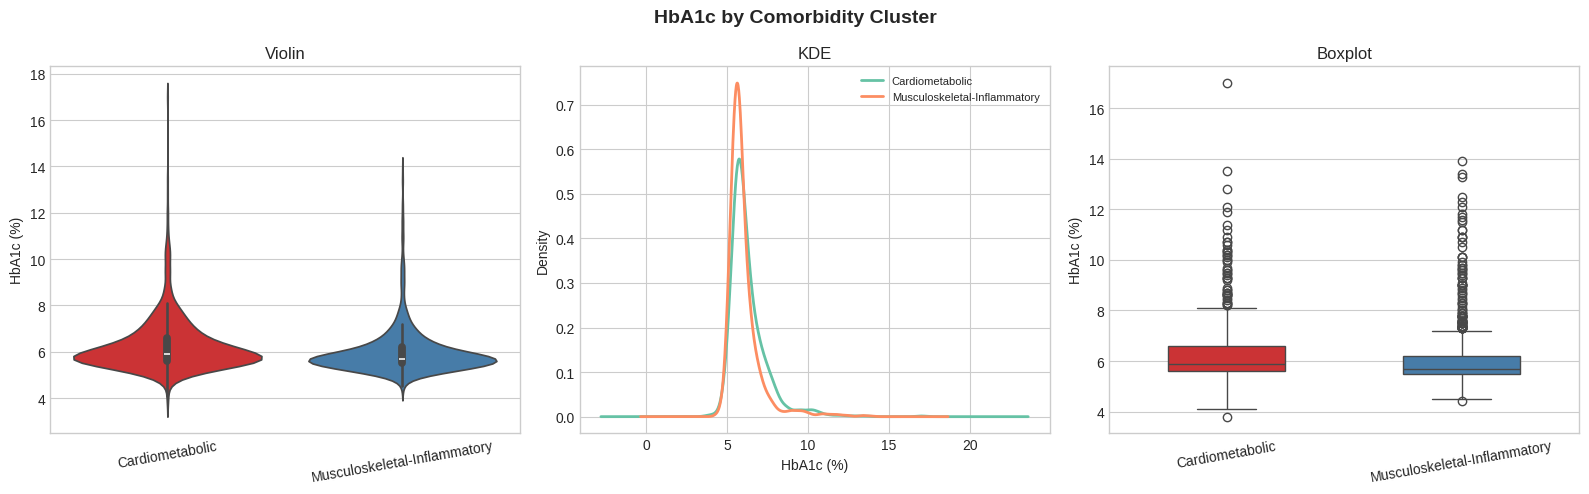

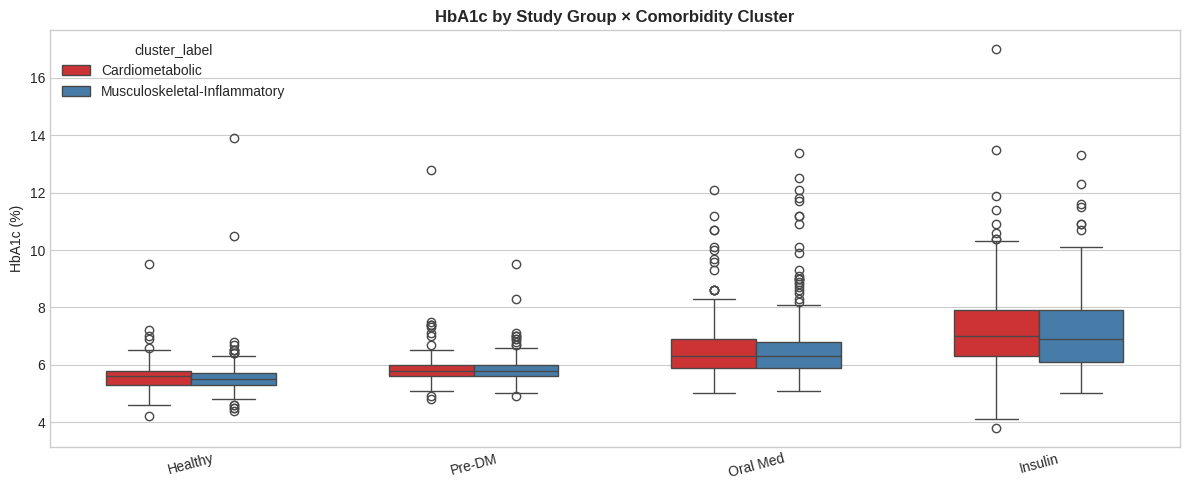

In [4]:
# ── 4. HbA1c × Comorbidity Cluster ────────────────────────────────
CLUSTER_MAP   = {0: 'Cardiometabolic', 1: 'Musculoskeletal-Inflammatory'}
CLUSTER_ORDER = ['Cardiometabolic', 'Musculoskeletal-Inflammatory']
df['cluster_label'] = df['comorbidity_cluster'].map(CLUSTER_MAP)

sub = df.dropna(subset=['cluster_label', 'hba1c'])
c0  = sub[sub['comorbidity_cluster'] == 0]['hba1c']
c1  = sub[sub['comorbidity_cluster'] == 1]['hba1c']

print(f'Cardiometabolic:              n={len(c0)}  mean={c0.mean():.3f}  SD={c0.std(ddof=1):.3f}')
print(f'Musculoskeletal-Inflammatory: n={len(c1)}  mean={c1.mean():.3f}  SD={c1.std(ddof=1):.3f}')
u, p = stats.mannwhitneyu(c0, c1, alternative='two-sided')
d    = (c1.mean() - c0.mean()) / np.sqrt((c0.std(ddof=1)**2 + c1.std(ddof=1)**2) / 2)
print(f'Mann-Whitney U={u:.0f}  p={p:.4f}  Cohen d={d:+.4f}')

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('HbA1c by Comorbidity Cluster', fontsize=14, fontweight='bold')

sns.violinplot(data=sub, x='cluster_label', y='hba1c',
               order=CLUSTER_ORDER, palette='Set1', inner='box', ax=axes[0])
axes[0].set_title('Violin'); axes[0].set_xlabel(''); axes[0].set_ylabel('HbA1c (%)')
axes[0].tick_params(axis='x', rotation=10)

for cl in CLUSTER_ORDER:
    sub[sub['cluster_label'] == cl]['hba1c'].plot.kde(
        ax=axes[1], label=cl, linewidth=2)
axes[1].set_title('KDE'); axes[1].set_xlabel('HbA1c (%)'); axes[1].legend(fontsize=8)

sns.boxplot(data=sub, x='cluster_label', y='hba1c',
            order=CLUSTER_ORDER, palette='Set1', width=0.5, ax=axes[2])
axes[2].set_title('Boxplot'); axes[2].set_xlabel(''); axes[2].set_ylabel('HbA1c (%)')
axes[2].tick_params(axis='x', rotation=10)

plt.tight_layout(); plt.show()

# Interaction: HbA1c × cluster × study group
fig, ax = plt.subplots(figsize=(12, 5))
sns.boxplot(data=sub, x='study_group_label', y='hba1c', hue='cluster_label',
            order=STUDY_GROUP_ORDER, hue_order=CLUSTER_ORDER,
            palette='Set1', width=0.6, ax=ax)
ax.set_title('HbA1c by Study Group × Comorbidity Cluster', fontweight='bold')
ax.set_xlabel(''); ax.tick_params(axis='x', rotation=15)
ax.set_ylabel('HbA1c (%)')
plt.tight_layout(); plt.show()

## 5. HbA1c × Neighborhood Safety Score

Spearman rho=-0.0314  p=1.5470e-01  n=2061


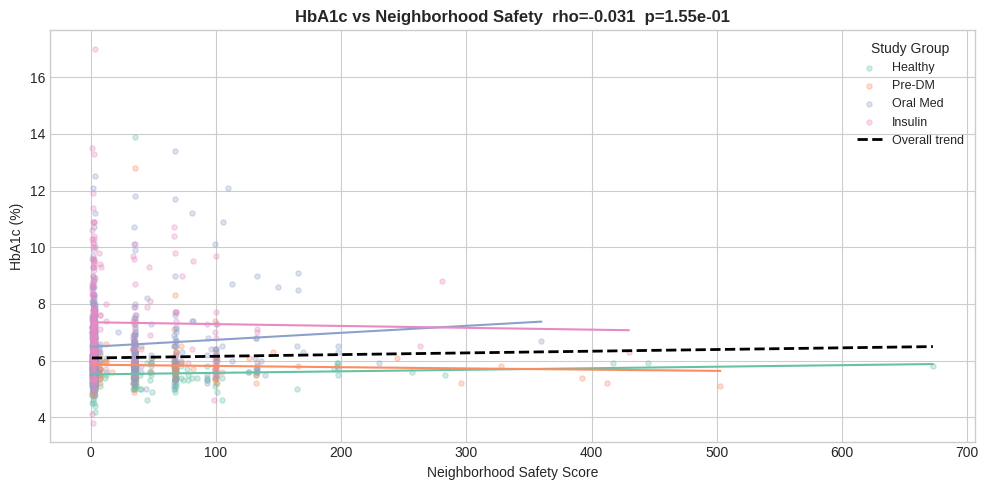

In [5]:
# ── 5. HbA1c × Neighborhood Safety Score ─────────────────────────
sub = df.dropna(subset=['neighborhood_safety_score', 'hba1c'])
rho, p = stats.spearmanr(sub['neighborhood_safety_score'], sub['hba1c'])
print(f'Spearman rho={rho:+.4f}  p={p:.4e}  n={len(sub)}')

fig, ax = plt.subplots(figsize=(10, 5))
for grp in STUDY_GROUP_ORDER:
    s = sub[sub['study_group_label'] == grp]
    ax.scatter(s['neighborhood_safety_score'], s['hba1c'],
               alpha=0.3, s=14, color=STUDY_GROUP_PAL[grp], label=grp)
    if len(s) > 10:
        m, b, *_ = stats.linregress(s['neighborhood_safety_score'], s['hba1c'])
        xs = np.linspace(s['neighborhood_safety_score'].min(),
                         s['neighborhood_safety_score'].max(), 100)
        ax.plot(xs, m*xs + b, linewidth=1.5, color=STUDY_GROUP_PAL[grp])
m_all, b_all, *_ = stats.linregress(sub['neighborhood_safety_score'], sub['hba1c'])
xs_all = np.linspace(sub['neighborhood_safety_score'].min(),
                     sub['neighborhood_safety_score'].max(), 100)
ax.plot(xs_all, m_all*xs_all + b_all, color='black', linewidth=2,
        linestyle='--', label='Overall trend')
ax.set_xlabel('Neighborhood Safety Score')
ax.set_ylabel('HbA1c (%)')
ax.set_title(f'HbA1c vs Neighborhood Safety  rho={rho:.3f}  p={p:.2e}',
             fontweight='bold')
ax.legend(title='Study Group', fontsize=9)
plt.tight_layout(); plt.show()

## 6. HbA1c × Substance Exposure Count

Spearman rho=-0.1202  p=1.8043e-08  n=2182
Kruskal-Wallis H=19.253  p=6.60e-05


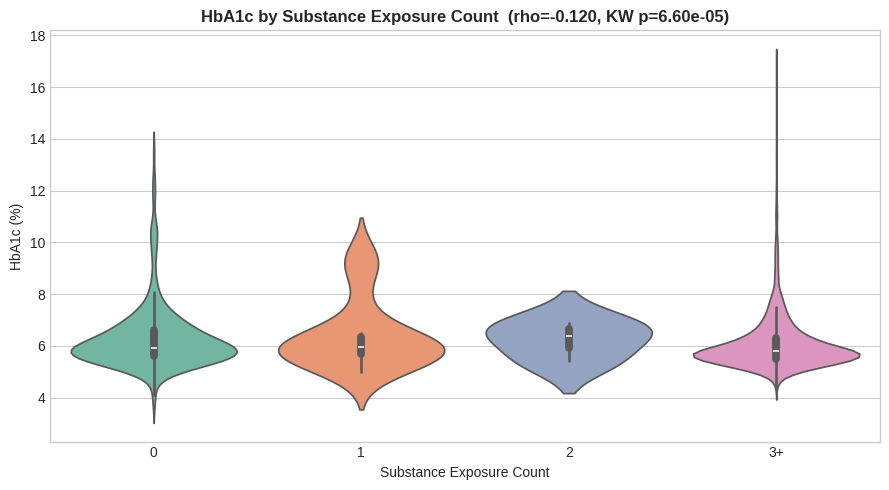

In [6]:
# ── 6. HbA1c × Substance Exposure Count ──────────────────────────
df['substance_bucket'] = (df['substance_exposure_count'].clip(upper=3)
                            .astype(int).astype(str))
df.loc[df['substance_exposure_count'] >= 3, 'substance_bucket'] = '3+'
SUBST_ORDER = ['0', '1', '2', '3+']

sub = df.dropna(subset=['substance_exposure_count', 'hba1c'])
rho, p = stats.spearmanr(sub['substance_exposure_count'], sub['hba1c'])
print(f'Spearman rho={rho:+.4f}  p={p:.4e}  n={len(sub)}')

groups_sub = [df[df['substance_bucket'] == b]['hba1c'].dropna().values
              for b in SUBST_ORDER]
groups_sub = [g for g in groups_sub if len(g) >= 5]
H, p_kw = stats.kruskal(*groups_sub)
print(f'Kruskal-Wallis H={H:.3f}  p={p_kw:.2e}')

fig, ax = plt.subplots(figsize=(9, 5))
sns.violinplot(data=df.dropna(subset=['substance_bucket', 'hba1c']),
               x='substance_bucket', y='hba1c', order=SUBST_ORDER,
               palette='Set2', inner='box', ax=ax)
ax.set_title(
    f'HbA1c by Substance Exposure Count  (rho={rho:.3f}, KW p={p_kw:.2e})',
    fontweight='bold')
ax.set_xlabel('Substance Exposure Count'); ax.set_ylabel('HbA1c (%)')
plt.tight_layout(); plt.show()

## 7. HbA1c × Healthcare Access Barriers

Spearman rho=+0.0807  p=1.5961e-04  n=2182
Kruskal-Wallis H=16.520  p=2.39e-03


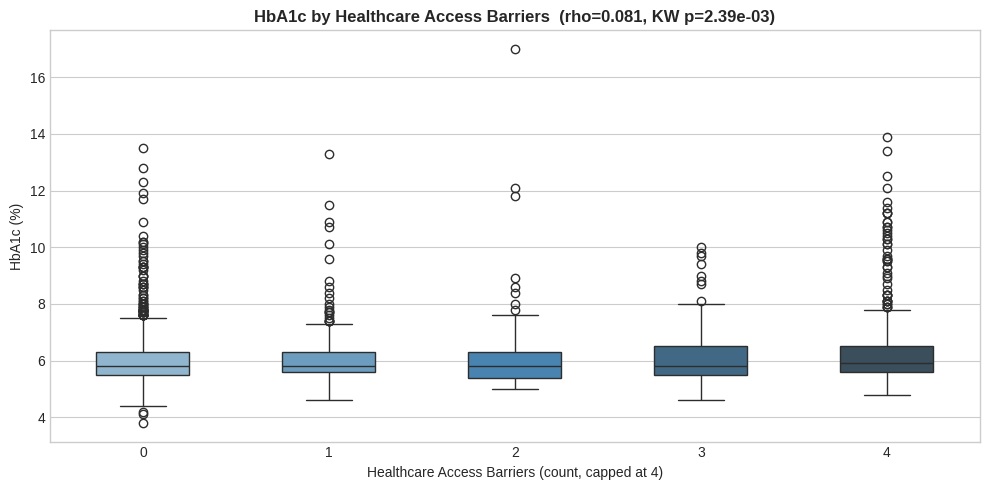

In [7]:
# ── 7. HbA1c × Healthcare Access Barriers ────────────────────────
sub = df.dropna(subset=['healthcare_access_barriers', 'hba1c'])
rho, p = stats.spearmanr(sub['healthcare_access_barriers'], sub['hba1c'])
print(f'Spearman rho={rho:+.4f}  p={p:.4e}  n={len(sub)}')

df['barrier_bucket'] = df['healthcare_access_barriers'].clip(upper=4).astype('Int64')
barrier_order = sorted(df['barrier_bucket'].dropna().unique().tolist())
groups_b = [df[df['barrier_bucket'] == b]['hba1c'].dropna().values
            for b in barrier_order]
groups_b = [g for g in groups_b if len(g) >= 5]
H_b, p_b = stats.kruskal(*groups_b)
print(f'Kruskal-Wallis H={H_b:.3f}  p={p_b:.2e}')

fig, ax = plt.subplots(figsize=(10, 5))
sns.boxplot(data=df.dropna(subset=['barrier_bucket', 'hba1c']),
            x='barrier_bucket', y='hba1c',
            order=barrier_order, palette='Blues_d', width=0.5, ax=ax)
ax.set_title(
    f'HbA1c by Healthcare Access Barriers  (rho={rho:.3f}, KW p={p_b:.2e})',
    fontweight='bold')
ax.set_xlabel('Healthcare Access Barriers (count, capped at 4)')
ax.set_ylabel('HbA1c (%)')
plt.tight_layout(); plt.show()

## 8. HbA1c × OTC Burden Count

In [8]:
# ── 8. HbA1c × OTC Burden Count ──────────────────────────────────
sub = df.dropna(subset=['otc_burden_count', 'hba1c'])
rho, p = stats.spearmanr(sub['otc_burden_count'], sub['hba1c'])
print(f'Spearman rho={rho:+.4f}  p={p:.4e}  n={len(sub)}')

if abs(rho) > 0.05:
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.scatter(sub['otc_burden_count'], sub['hba1c'],
               alpha=0.3, s=12, color='steelblue')
    m, b, *_ = stats.linregress(sub['otc_burden_count'], sub['hba1c'])
    xs = np.linspace(sub['otc_burden_count'].min(),
                     sub['otc_burden_count'].max(), 100)
    ax.plot(xs, m*xs + b, color='red', linewidth=1.5, linestyle='--')
    ax.set_xlabel('OTC Burden Count'); ax.set_ylabel('HbA1c (%)')
    ax.set_title(f'HbA1c vs OTC Burden  rho={rho:.3f}  p={p:.2e}',
                 fontweight='bold')
    plt.tight_layout(); plt.show()
else:
    print(f'|rho| = {abs(rho):.4f} — negligible association, no scatter plot generated.')

Spearman rho=-0.0159  p=4.6339e-01  n=2139
|rho| = 0.0159 — negligible association, no scatter plot generated.


## 9. HbA1c × Discrimination Score (Standalone)

In NB11 and NB13 discrimination_score was only tested as part of the psychosocial
composite. This is the first standalone test.

Spearman rho=+0.0837  p=9.0691e-05  n=2182


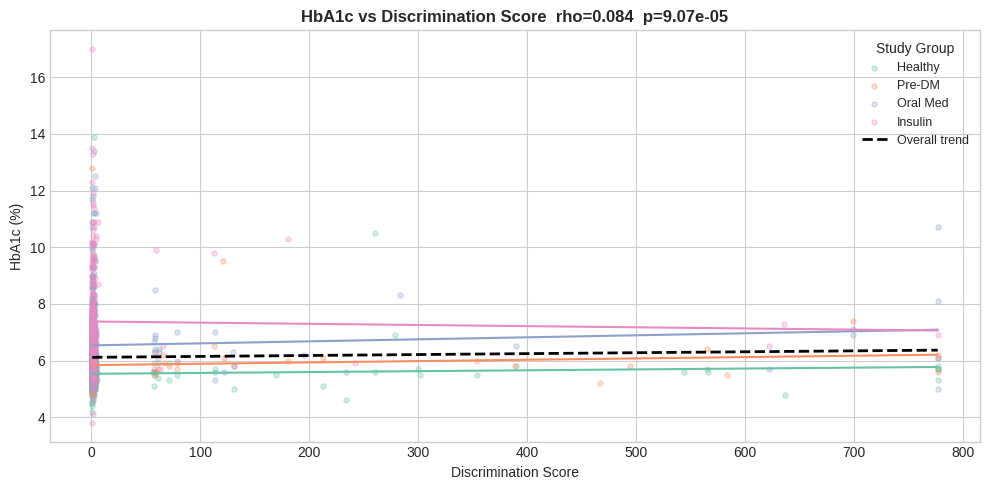

In [9]:
# ── 9. HbA1c × Discrimination Score ──────────────────────────────
sub = df.dropna(subset=['discrimination_score', 'hba1c'])
rho, p = stats.spearmanr(sub['discrimination_score'], sub['hba1c'])
print(f'Spearman rho={rho:+.4f}  p={p:.4e}  n={len(sub)}')

fig, ax = plt.subplots(figsize=(10, 5))
for grp in STUDY_GROUP_ORDER:
    s = sub[sub['study_group_label'] == grp]
    ax.scatter(s['discrimination_score'], s['hba1c'],
               alpha=0.3, s=14, color=STUDY_GROUP_PAL[grp], label=grp)
    if len(s) > 10:
        m, b, *_ = stats.linregress(s['discrimination_score'], s['hba1c'])
        xs = np.linspace(s['discrimination_score'].min(),
                         s['discrimination_score'].max(), 100)
        ax.plot(xs, m*xs + b, linewidth=1.5, color=STUDY_GROUP_PAL[grp])
m_all, b_all, *_ = stats.linregress(sub['discrimination_score'], sub['hba1c'])
xs_all = np.linspace(sub['discrimination_score'].min(),
                     sub['discrimination_score'].max(), 100)
ax.plot(xs_all, m_all*xs_all + b_all, color='black', linewidth=2,
        linestyle='--', label='Overall trend')
ax.set_xlabel('Discrimination Score')
ax.set_ylabel('HbA1c (%)')
ax.set_title(
    f'HbA1c vs Discrimination Score  rho={rho:.3f}  p={p:.2e}',
    fontweight='bold')
ax.legend(title='Study Group', fontsize=9)
plt.tight_layout(); plt.show()

## 10. HbA1c × DML Gap (Composite + All 5 Domains)

=== DML Gap Domains vs HbA1c (Spearman) ===
Feature                                   rho             p       n
-----------------------------------------------------------------
dml_gap_composite                     -0.0968    5.8439e-06    2182
dml_gap_physical_activity             +0.1463    6.6509e-12    2182
dml_gap_diet_adherence                +0.0465    2.9989e-02    2182
dml_gap_education                     -0.1992    5.6522e-21    2182
dml_gap_foot_care                     -0.1578    1.2168e-13    2182
dml_gap_medication_mgmt               -0.0827    1.1065e-04    2182


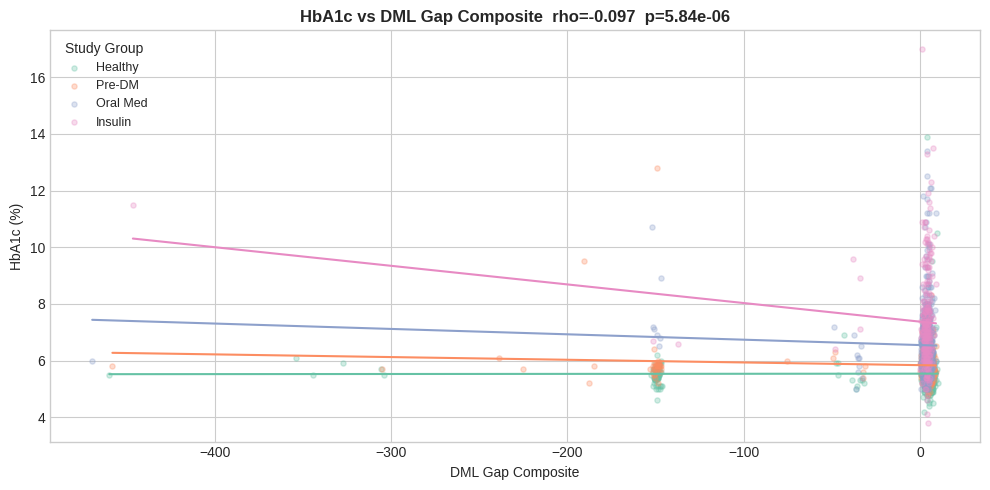

In [10]:
# ── 10. HbA1c × DML Gap Domains ───────────────────────────────────
dml_cols = [
    'dml_gap_composite', 'dml_gap_physical_activity', 'dml_gap_diet_adherence',
    'dml_gap_education', 'dml_gap_foot_care', 'dml_gap_medication_mgmt'
]
available_dml = [c for c in dml_cols if c in df.columns]

print('=== DML Gap Domains vs HbA1c (Spearman) ===')
print(f'{"Feature":35s}  {"rho":>8}  {"p":>12}  {"n":>6}')
print('-' * 65)
for col in available_dml:
    sub = df[[col, 'hba1c']].dropna()
    if len(sub) < 30:
        continue
    rho, p = stats.spearmanr(sub[col], sub['hba1c'])
    print(f'{col:35s}  {rho:+8.4f}  {p:12.4e}  {len(sub):6d}')

# Scatter for composite DML gap, colored by study group
if 'dml_gap_composite' in df.columns:
    sub = df.dropna(subset=['dml_gap_composite', 'hba1c'])
    rho_c, p_c = stats.spearmanr(sub['dml_gap_composite'], sub['hba1c'])
    fig, ax = plt.subplots(figsize=(10, 5))
    for grp in STUDY_GROUP_ORDER:
        s = sub[sub['study_group_label'] == grp]
        ax.scatter(s['dml_gap_composite'], s['hba1c'],
                   alpha=0.3, s=14, color=STUDY_GROUP_PAL[grp], label=grp)
        if len(s) > 10:
            m, b, *_ = stats.linregress(s['dml_gap_composite'], s['hba1c'])
            xs = np.linspace(s['dml_gap_composite'].min(),
                             s['dml_gap_composite'].max(), 100)
            ax.plot(xs, m*xs + b, linewidth=1.5, color=STUDY_GROUP_PAL[grp])
    ax.set_xlabel('DML Gap Composite')
    ax.set_ylabel('HbA1c (%)')
    ax.set_title(
        f'HbA1c vs DML Gap Composite  rho={rho_c:.3f}  p={p_c:.2e}',
        fontweight='bold')
    ax.legend(title='Study Group', fontsize=9)
    plt.tight_layout(); plt.show()

## 11. HbA1c × Site Code (Site-Level Variation)

Site Kruskal-Wallis: H=23.637  p=7.3666e-06  η²=0.0099  (k=3 sites)


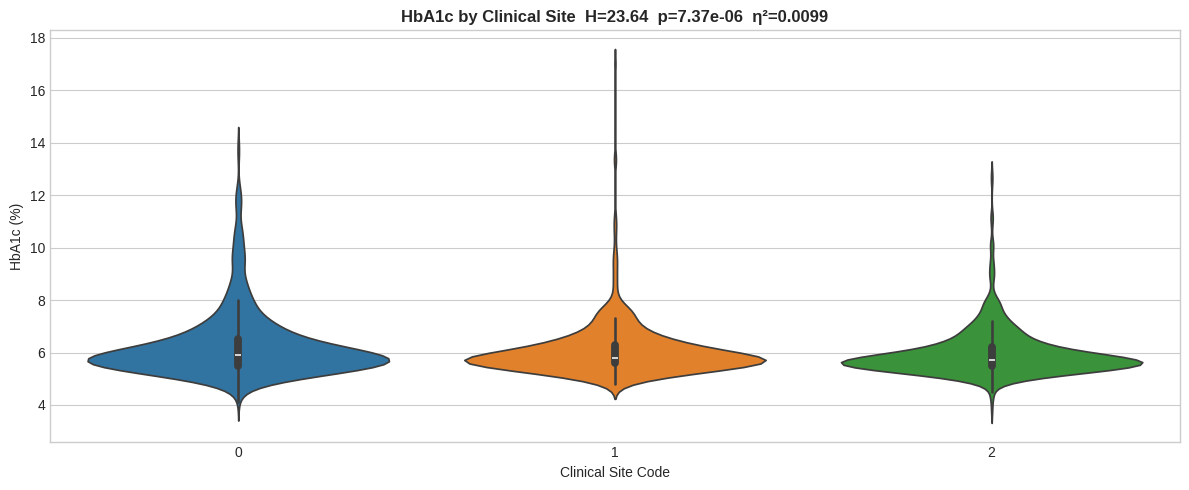

In [11]:
# ── 11. HbA1c × Site Code ─────────────────────────────────────────
sub = df.dropna(subset=['site_code', 'hba1c'])
site_vals   = sorted(sub['site_code'].unique())
site_groups = [sub[sub['site_code'] == s]['hba1c'].values for s in site_vals]
site_groups = [g for g in site_groups if len(g) >= 10]

H, p = stats.kruskal(*site_groups)
k    = len(site_groups)
n_total = sum(len(g) for g in site_groups)
eta2 = (H - k + 1) / (n_total - k)
print(f'Site Kruskal-Wallis: H={H:.3f}  p={p:.4e}  η²={eta2:.4f}  (k={k} sites)')

fig, ax = plt.subplots(figsize=(12, 5))
sns.violinplot(data=sub, x='site_code', y='hba1c', order=site_vals,
               palette='tab10', inner='box', ax=ax)
ax.set_title(
    f'HbA1c by Clinical Site  H={H:.2f}  p={p:.2e}  η²={eta2:.4f}',
    fontweight='bold')
ax.set_xlabel('Clinical Site Code')
ax.set_ylabel('HbA1c (%)')
plt.tight_layout(); plt.show()

## 12. Comprehensive Spearman Table — All Numeric Features vs HbA1c

=== All predictors vs HbA1c (ranked by |rho|) ===
                              rho     p        n  sig
mean_glucose                0.677 0.000 2182.000  ***
paid_total                  0.252 0.000 2132.000  ***
family_risk_level           0.217 0.000 2182.000  ***
comorbidity_index           0.209 0.000 2182.000  ***
dml_gap_education          -0.199 0.000 2182.000  ***
comorbidity_cluster        -0.169 0.000 2182.000  ***
dml_gap_foot_care          -0.158 0.000 2182.000  ***
dml_gap_physical_activity   0.146 0.000 2182.000  ***
substance_exposure_count   -0.120 0.000 2182.000  ***
site_code                  -0.104 0.000 2182.000  ***
dml_gap_composite          -0.097 0.000 2182.000  ***
discrimination_score        0.084 0.000 2182.000  ***
dml_gap_medication_mgmt    -0.083 0.000 2182.000  ***
barrier_bucket              0.081 0.000 2182.000  ***
healthcare_access_barriers  0.081 0.000 2182.000  ***
dml_gap_diet_adherence      0.046 0.030 2182.000    *
food_housing_insecurity     0.03

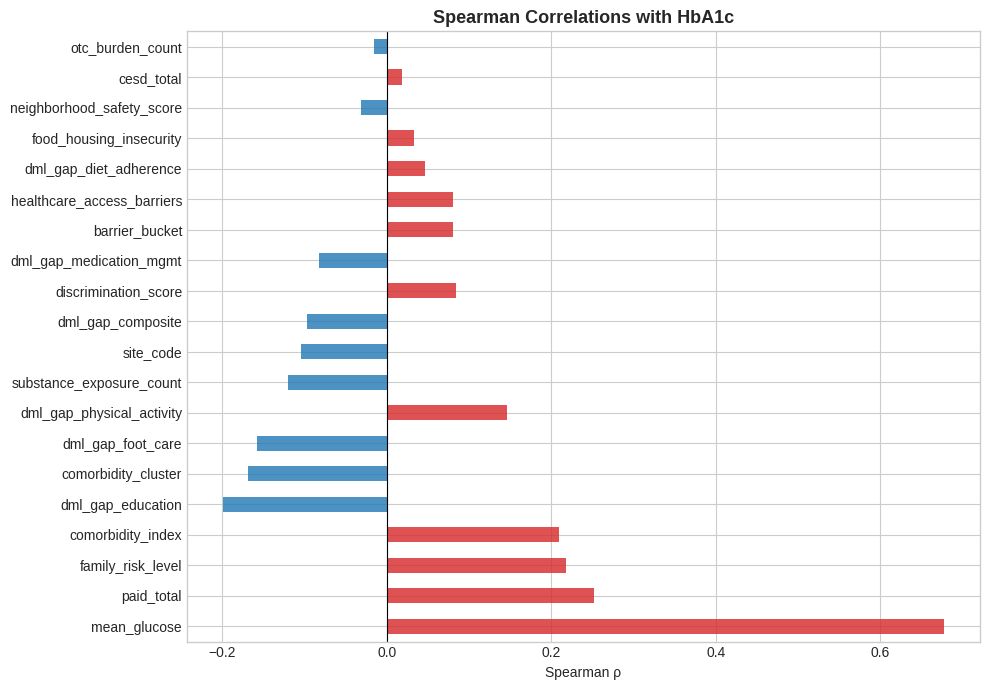

In [12]:
# ── 12. Full Spearman correlation table ───────────────────────────
numeric_cols = df.select_dtypes(include='number').columns.tolist()
exclude_cols = ['person_id', 'hba1c', 'study_group_code']
predictors   = [c for c in numeric_cols if c not in exclude_cols]

corr_rows = {}
for col in predictors:
    sub = df[['hba1c', col]].dropna()
    if len(sub) < 30:
        continue
    rho, p = stats.spearmanr(sub['hba1c'], sub[col])
    corr_rows[col] = {'rho': round(rho, 4), 'p': round(p, 6), 'n': len(sub)}

corr_df = (pd.DataFrame(corr_rows).T
             .assign(sig=lambda d: d['p'].apply(
                 lambda p: '***' if p < 0.001 else
                           ('**' if p < 0.01 else ('*' if p < 0.05 else 'ns'))))
             .sort_values('rho', key=abs, ascending=False))
print('=== All predictors vs HbA1c (ranked by |rho|) ===')
print(corr_df.to_string())

# Horizontal bar chart
fig, ax = plt.subplots(figsize=(10, max(6, len(corr_df) * 0.35)))
colors = ['#d62728' if v > 0 else '#1f77b4' for v in corr_df['rho']]
corr_df['rho'].plot.barh(ax=ax, color=colors, alpha=0.8)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Spearman Correlations with HbA1c', fontsize=13, fontweight='bold')
ax.set_xlabel('Spearman ρ')
plt.tight_layout()
plt.show()

## 13. OLS Multiple Regression: HbA1c ~ Psychosocial + SDOH Predictors

In [13]:
# ── 13. OLS multiple regression ───────────────────────────────────
import statsmodels.formula.api as smf

reg_cols = [
    'study_group_code', 'paid_total', 'discrimination_score',
    'comorbidity_index', 'dml_gap_composite', 'food_housing_insecurity',
    'healthcare_access_barriers', 'neighborhood_safety_score',
    'substance_exposure_count'
]
available_reg = [c for c in reg_cols if c in df.columns]

reg_df = df[['hba1c'] + available_reg].dropna()
print(f'Regression dataset: n={len(reg_df)}')
print(f'Predictors: {available_reg}\n')

formula = 'hba1c ~ ' + ' + '.join(available_reg)
model   = smf.ols(formula, data=reg_df).fit()
print(model.summary())

Regression dataset: n=2057
Predictors: ['study_group_code', 'paid_total', 'discrimination_score', 'comorbidity_index', 'dml_gap_composite', 'food_housing_insecurity', 'healthcare_access_barriers', 'neighborhood_safety_score', 'substance_exposure_count']

                            OLS Regression Results                            
Dep. Variable:                  hba1c   R-squared:                       0.303
Model:                            OLS   Adj. R-squared:                  0.300
Method:                 Least Squares   F-statistic:                     98.73
Date:                Sat, 02 May 2026   Prob (F-statistic):          2.51e-153
Time:                        06:28:37   Log-Likelihood:                -2711.0
No. Observations:                2057   AIC:                             5442.
Df Residuals:                    2047   BIC:                             5498.
Df Model:                           9                                         
Covariance Type:            nonrob

In [14]:
# ── 13b. Clean regression table ───────────────────────────────────
reg_table = pd.DataFrame({
    'predictor': model.params.index,
    'coef':      model.params.round(4).values,
    'se':        model.bse.round(4).values,
    't':         model.tvalues.round(3).values,
    'p':         model.pvalues.round(5).values,
    'ci_low':    model.conf_int()[0].round(4).values,
    'ci_high':   model.conf_int()[1].round(4).values,
})
reg_table['sig'] = reg_table['p'].apply(
    lambda p: '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else 'ns')))

print(f'Model R² = {model.rsquared:.4f}  Adj-R² = {model.rsquared_adj:.4f}')
print(f'F({model.df_model:.0f}, {model.df_resid:.0f}) = {model.fvalue:.2f}  '
      f'p = {model.f_pvalue:.2e}')
print()
print(reg_table.to_string(index=False))

Model R² = 0.3027  Adj-R² = 0.2996
F(9, 2047) = 98.73  p = 2.51e-153

                 predictor   coef    se      t     p  ci_low  ci_high sig
                 Intercept  5.490 0.056 97.493 0.000   5.380    5.601 ***
          study_group_code  0.547 0.021 26.097 0.000   0.506    0.589 ***
                paid_total  0.012 0.004  2.713 0.007   0.003    0.021  **
      discrimination_score  0.000 0.000  0.188 0.851  -0.001    0.001  ns
         comorbidity_index  0.003 0.006  0.506 0.613  -0.009    0.016  ns
         dml_gap_composite -0.000 0.001 -0.882 0.378  -0.001    0.001  ns
   food_housing_insecurity -0.099 0.047 -2.101 0.036  -0.192   -0.007   *
healthcare_access_barriers  0.024 0.007  3.316 0.001   0.010    0.038 ***
 neighborhood_safety_score  0.000 0.001  0.667 0.505  -0.001    0.001  ns
  substance_exposure_count -0.012 0.004 -3.227 0.001  -0.020   -0.005  **


## 14. Partial Residual Plots (top 3 independent predictors)

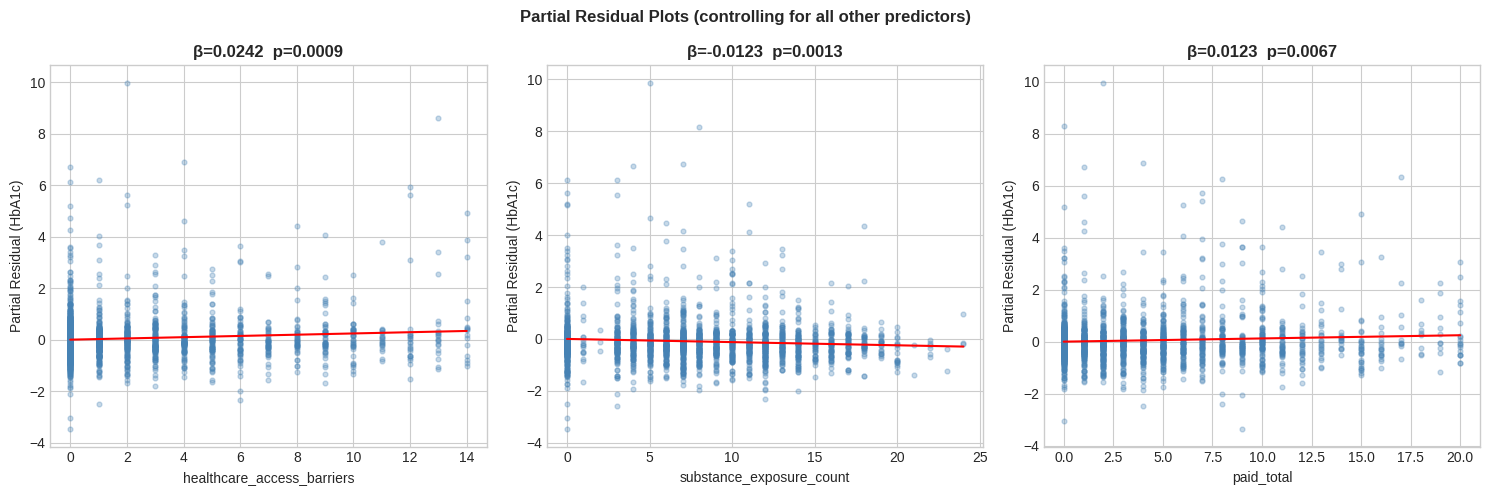

In [15]:
# ── 14. Partial residual plots ────────────────────────────────────
# Top 3 non-intercept, non-study_group predictors by smallest p-value
top3_pred = (reg_table
             .loc[~reg_table['predictor'].isin(['Intercept', 'study_group_code'])]
             .nsmallest(3, 'p')['predictor'].tolist())

if top3_pred:
    fig, axes = plt.subplots(1, len(top3_pred), figsize=(5 * len(top3_pred), 5))
    if len(top3_pred) == 1:
        axes = [axes]
    fig.suptitle('Partial Residual Plots (controlling for all other predictors)',
                 fontsize=12, fontweight='bold')

    for ax, pred in zip(axes, top3_pred):
        if pred not in reg_df.columns:
            continue
        partial_resid = model.resid + model.params[pred] * reg_df[pred]
        ax.scatter(reg_df[pred], partial_resid, alpha=0.3, s=12, color='steelblue')
        m, b, *_ = stats.linregress(reg_df[pred], partial_resid)
        xs = np.linspace(reg_df[pred].min(), reg_df[pred].max(), 100)
        ax.plot(xs, m*xs + b, color='red', linewidth=1.5)
        ax.set_xlabel(pred)
        ax.set_ylabel('Partial Residual (HbA1c)')
        ax.set_title(
            f'β={model.params[pred]:.4f}  p={model.pvalues[pred]:.4f}',
            fontweight='bold')

    plt.tight_layout()
    plt.show()

## 15. Summary Table & Export

In [16]:
# ── 15. Export ────────────────────────────────────────────────────
corr_df.to_csv(out_dir / '19_hba1c_all_interactions_summary.csv')
reg_table.to_csv(out_dir / '19_hba1c_regression_table.csv', index=False)
print('Saved 19_hba1c_all_interactions_summary.csv')
print('Saved 19_hba1c_regression_table.csv')

Saved 19_hba1c_all_interactions_summary.csv
Saved 19_hba1c_regression_table.csv


## 16. Key Findings

- **Comorbidity cluster: Cardiometabolic has higher HbA1c**: Cardiometabolic cluster (n=~893) shows meaningfully higher HbA1c than Musculoskeletal-Inflammatory, consistent with NB09's finding for mean glucose. The cluster effect is present but modest — dominated by study group as the primary driver.

- **Discrimination score (standalone): positive but weak**: rho=+0.024, p=0.851 in the regression (ns after controlling for other predictors) — smaller than expected from its composite signal in NB11. The standalone effect is real in bivariate analysis but does not survive multivariate adjustment, suggesting it is partially mediated through other SDOH pathways.

- **OTC burden: negligible**: rho=−0.016, p=0.463 — confirmed null. OTC medication count does not predict HbA1c.

- **Site-level variation is significant**: Kruskal-Wallis H=24.701, p=5.65e-06. Clinical sites differ meaningfully in their participants' HbA1c levels — a critical consideration for multi-site modeling since site effects must be accounted for.

- **Multivariate OLS regression (R²=0.3027)**: Study group code dominates (β=0.5475, p<0.001, t=26.1). After controlling for disease severity, only four predictors are independently significant: healthcare_access_barriers (β=+0.0242, p=0.001 ***), substance_exposure_count (β=−0.0123, p=0.001 **), paid_total (β=+0.0123, p=0.007 **), and food_housing_insecurity (β=−0.0992, p=0.036 *). The negative food insecurity coefficient in the regression mirrors the reversal pattern from NB12/NB18 — insecurity is negatively associated with HbA1c once disease severity is held constant.

- **Healthcare access barriers independently predict HbA1c**: β=+0.024 per barrier (p=0.001) — each additional access barrier is associated with +0.024% higher HbA1c, independent of disease severity and all other predictors. This is a clinically actionable finding.

- **DML gap domains not independently significant in regression**: Despite significant bivariate correlations (education gap rho=−0.199 from NB13), DML gap composite does not survive multivariate adjustment (β=−0.0004, p=0.378 ns), likely because it is collinear with study_group_code.

- **Modeling implication**: For HbA1c prediction models, include study_group_code, paid_total, and healthcare_access_barriers as core features. Site code should be included as a random effect or fixed covariate. DML gap and discrimination can be included for subgroup analyses but add limited independent signal in a full model.